<a href="https://colab.research.google.com/github/python4recursion/bookcode/blob/main/CH04/4_maze.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# CH04: maze.py
from enum import Enum
class Direction(Enum):
    NORTH = 0
    EAST  = 1
    SOUTH = 2
    WEST  = 3
class Maze:
    def __init__(self, filename):
        self.path = {}
        self.readMaze(filename)
    def readMaze(self, filename):
        # read maze from a file
        fhd = open(filename, 'r')
        self.lines = fhd.readlines()
        # remove ending '\n'
        self.lines = [line.strip() for line in self.lines]
        fhd.close()
        self.numrow = len(self.lines)
        # length of the longest line
        self.numcol = len(max(self.lines, key=len))
        self.mazesize = self.numrow * self.numcol
        self.longest = self.mazesize
        # create a 2-D matrix keeping the distance
        # the distance initialized to mazesize
        # because mazesize is larger than any possible
        # distance from the starting point
        self.distances = [[self.mazesize for i in range(0, self.numcol)]
                          for j in range(0, self.numrow)]
        # find the exit and the starting point
        for r in range(0, self.numrow):
            cs = self.lines[r].find('s') # cell of starting point
            if (cs != -1):
                self.startrow = r
                self.startcol = cs
                self.distances[r][cs] = 0
            ce = self.lines[r].find('E') # cell of exit
            if (ce != -1):
                self.exitrow = r
                self.exitcol = ce
            # go through the columns, assign -1 to the cells of bricks
            for c in range(0, len(self.lines[r])):
                if (self.lines[r][c] == 'b'):
                    self.distances[r][c] = -1
            # if the maze is not rectangular, assign -1 to the ending elements
            for c in range(len(self.lines[r]), self.numcol):
                self.distances[r][c] = -1
    def getDistance(self, row, col, dir):
        # return -1 for invalid move or a brick
        if (dir == Direction.NORTH):
            row = row - 1
        if (row < 0):
            return -1
        if (dir == Direction.SOUTH):
            row = row + 1
        if (row >= self.numrow):
            return -1
        if (dir == Direction.WEST):
            col = col - 1
        if (col < 0):
            return -1
        if (dir == Direction.EAST):
            col = col + 1
        if (col >= len(self.lines[row])):
            return -1
        # row and col are valid
        if (self.lines[row][col] == 'b'):
            return -1 # cannot enter a brick
        if (self.lines[row][col] == 's'):
            self.distances[row][col] = 0
            return 0 # distance of the starting point is zero
        # return the current distance from the starting point
        return self.distances[row][col]
    def move(self, row, col, distance):
        self.distances[row][col] = distance
        self.path[(row, col)] = distance
        if (distance == -1):
            print ("ERROR, enter a brick")
            return
        if (self.lines[row][col] == 'E'): # reach the exit
            return
        # move to a cell only if doing so can shorten the distance
        dist = self.getDistance(row, col, Direction.EAST)
        # moving to a neighbor
        if (dist > (distance + 1)):
            self.move(row, col + 1, distance + 1)
        dist = self.getDistance(row, col, Direction.WEST)
        if (dist > (distance + 1)):
            self.move(row, col - 1, distance + 1)
        dist = self.getDistance(row, col, Direction.NORTH)
        if (dist > (distance + 1)):
            self.move(row - 1, col, distance + 1)
        dist = self.getDistance(row, col, Direction.SOUTH)
        if (dist > (distance + 1)):
            self.move(row + 1, col, distance + 1)
    def solve(self):
        self.move(self.startrow, self.startcol, 0)
        r = self.exitrow
        c = self.exitcol
        if (r, c) in self.path:
            d = self.path[(r,c)]
            print(f'distance from start to exit: {str(d)}')
        else:
            print(f'Exit at ({r}, {c}) is unreachable.')
        # replace the largest distances by -1 because not reachable
        # also find the longest distance
        self.longest = 0
        for r in range(0, self.numrow):
            for c in range(0, len(self.lines[r])):
                if (self.distances[r][c] == self.mazesize):
                    self.distances[r][c] = -1
                if (self.longest < self.distances[r][c]):
                    self.longest = self.distances[r][c]
    def print(self):
        print (f'start at ({str(self.startrow)}, {str(self.startcol)})')
        print (f'numrow = {self.numrow}, numcol = {self.numcol}')
        print (f'exit at ({str(self.exitrow)}, {str(self.exitcol)})')
        for r in range(0, self.numrow):
          for c in range(0, len(self.lines[r])):
            print("{:6d}".format(self.distances[r][c]), end='')
          print() # add line break
        '''
        print ('path from start to exit:')
        for k in (self.path.keys()):
          print(k, end = '')
          # print (f"({k[0]:3d}, {k[1]:3d})", end = '')
        print() # add line break
        '''
    def getPath(self):
        return self.path
    def getLines(self):
        return self.lines
    def getHeight(self):
        return self.numrow
    def getWidth(self):
        return self.numcol

In [ ]:
!git clone https://github.com/python4recursion/bookcode.git
!ls -F bookcode/CH04/inputs/

Cloning into 'bookcode'...
remote: Enumerating objects: 200, done.
remote: Counting objects: 100% (200/200), done.
remote: Compressing objects: 100% (169/169), done.
remote: Total 200 (delta 70), reused 69 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (200/200), 972.57 KiB | 4.52 MiB/s, done.
Resolving deltas: 100% (70/70), done.
maze1  maze10  maze11  maze2  maze3  maze4  maze5  maze6  maze7  maze8	maze9


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
import numpy as np
from matplotlib.colors import ListedColormap
def draw_heatmap(maz, filename):
  # Create a custom colormap
  # Use black for -1, and 'coolwarm' for other values
  colors = plt.cm.coolwarm(np.linspace(0, 1, 256))
  colors[0] = [0.95, 0.95, 0.95, 1]  # Set the first color (corresponding to -1) to black
  # the first three numbers correspond to RGB (red, green, and blue)
  # the values should between 0 and 1
  custom_cmap = ListedColormap(colors)
  fig = plt.figure(figsize=(maz.numcol/2, maz.numrow/2))
  sns.heatmap(maz.distances, annot= True, cmap=custom_cmap, cbar=False, vmin = -1, vmax = maz.longest, xticklabels=False, yticklabels=False)
  plt.show()
  filename += ".pdf"
  print(filename)
  fig.savefig(filename)

filepath = bookcode/4/inputs/maze1
Processing file: bookcode/4/inputs/maze1
distance from start to exit: 10
start at (3, 9)
numrow = 11, numcol = 11
exit at (0, 4)
    -1    -1    -1    -1    10    -1    -1    -1    -1    -1    -1
    -1    10     9     8     9    10    11    12    13    14    -1
    -1    11    -1     7    -1    -1    -1    -1    -1    -1    -1
    -1    12    -1     6     5     4     3     2     1     0    -1
    -1    13    -1     7    -1    -1     4    -1    -1    -1    -1
    -1    12    -1     8     9    10    -1    14    15    16    -1
    -1    11    10     9    -1    11    12    13    -1    -1    -1
    -1    -1    11    -1    -1    12    -1    14    15    16    -1
    -1    13    12    -1    14    13    14    -1    -1    17    -1
    -1    -1    13    -1    15    -1    15    16    -1    18    -1
    -1    -1    -1    -1    -1    -1    -1    -1    -1    -1    -1


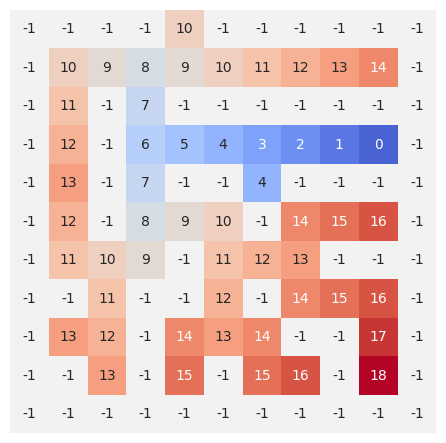

maze1.pdf
filepath = bookcode/4/inputs/maze10
Processing file: bookcode/4/inputs/maze10
distance from start to exit: 11
start at (8, 9)
numrow = 16, numcol = 16
exit at (8, 0)
    -1    -1    -1    -1
    -1    17    16    17    -1
    -1    16    15    -1    13    12    -1
    -1    15    14    -1    12    11    -1    -1    -1
    -1    14    13    14    -1    10     9    -1    13    12    -1
    -1    13    12    -1    10     9     8     9    -1    11    10     9    -1
    -1    12    11    10     9     8     7     8     9    10     9     8     7    -1
    -1    -1    -1    -1    -1    -1     6     7    -1    -1    -1     7     6     7    -1
    11    10     9     8    -1     6     5    -1     1     0     1    -1     5     6     7    -1
    -1     9     8     7     6     5     4     3     2     1     2     3     4    -1
    -1    10     9     8     7    -1     5     4     3     2     3    -1
    -1    11    10     9     8     9    -1     5     4     3    -1
    -1    12    11    10  

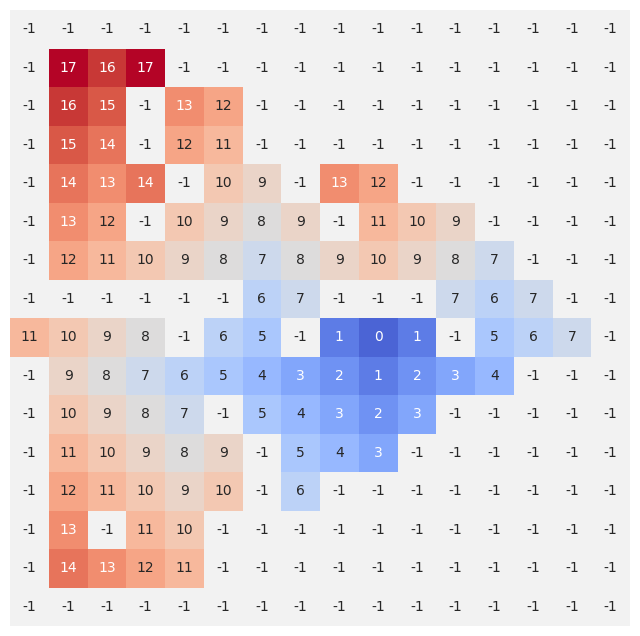

maze10.pdf
filepath = bookcode/4/inputs/maze11
Processing file: bookcode/4/inputs/maze11
distance from start to exit: 20
start at (3, 9)
numrow = 9, numcol = 11
exit at (6, 10)
    -1    -1    -1    -1    -1    11    -1    -1    -1    -1    -1
    -1    10     9     8     9    10    11    12    13    14    -1
    -1    11    -1     7    -1    -1    -1    -1    -1    -1    -1
    -1    12    -1     6     5     4     3     2     1     0    -1
    -1    11    -1     7    -1    -1     4    -1    -1    -1    -1
    -1    10     9     8     9    10    -1    16    17    18    -1
    -1    -1    10    -1    -1    11    -1    15    -1    19    20
    -1    12    11    -1    13    12    13    14    -1    20    -1
    -1    -1    -1    -1    -1    -1    -1    -1    -1    -1    -1


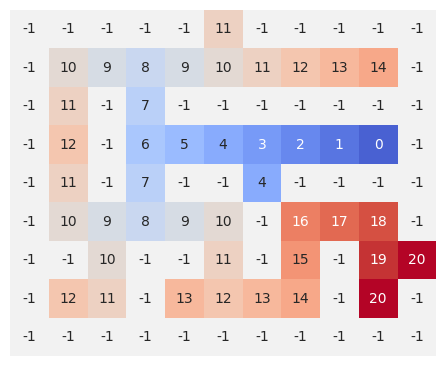

maze11.pdf
filepath = bookcode/4/inputs/maze2
Processing file: bookcode/4/inputs/maze2
distance from start to exit: 7
start at (3, 9)
numrow = 9, numcol = 11
exit at (0, 5)
    -1    -1    -1    -1    -1     7    -1    -1    -1    -1    -1
    -1    10     9     8     7     6     5     4     3     2    -1
    -1    11    -1     9    -1     7    -1    -1    -1     1    -1
    -1    12    -1    10     9     8    -1     2     1     0    -1
    -1    13    -1    -1    10    -1    -1    -1    -1     1    -1
    -1    14    13    12    11    -1    -1     4     3     2    -1
    -1    -1    14    -1    -1    -1    -1     5    -1     3    -1
    -1    16    15    16    17    -1     7     6    -1     4    -1
    -1    -1    -1    -1    -1    -1    -1    -1    -1    -1    -1


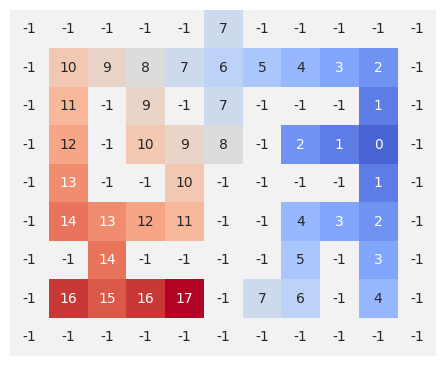

maze2.pdf
filepath = bookcode/4/inputs/maze3
Processing file: bookcode/4/inputs/maze3
distance from start to exit: 10
start at (3, 9)
numrow = 9, numcol = 11
exit at (8, 4)
    -1    -1    -1    -1    -1    -1    -1    -1    -1    -1    -1
    -1    10     9     8     7     6     5     4     5     6    -1
    -1    11    -1     7    -1    -1    -1     3    -1    -1    -1
    -1    12    -1     6     5     4     3     2     1     0    -1
    -1    11    -1    -1     6    -1    -1     3    -1    -1    -1
    -1    10     9     8     7     8    -1     4     5     6    -1
    -1    -1    -1    -1    -1     9    -1     5    -1     7    -1
    -1    12    11    10     9     8     7     6    -1     8    -1
    -1    -1    -1    -1    10    -1    -1    -1    -1    -1    -1


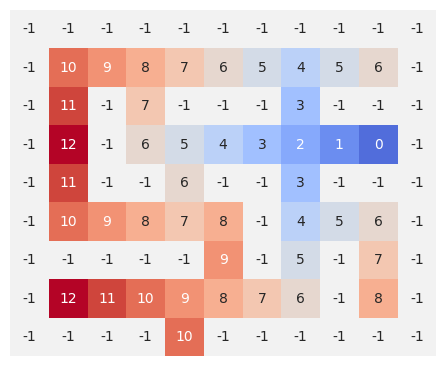

maze3.pdf
filepath = bookcode/4/inputs/maze4
Processing file: bookcode/4/inputs/maze4
distance from start to exit: 9
start at (7, 5)
numrow = 9, numcol = 7
exit at (0, 3)
    -1    -1    -1     9    -1    -1    -1
    -1    10     9     8     9    10    -1
    -1    -1    -1     7    -1    -1    -1
    -1     8     7     6     5     4    -1
    -1     9    -1    -1    -1     3    -1
    -1    10    -1    16    -1     2    -1
    -1    11    -1    15    -1     1    -1
    -1    12    13    14    -1     0    -1
    -1    -1    -1    -1    -1    -1    -1


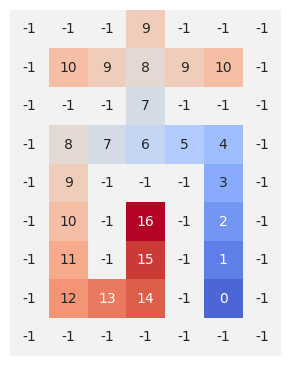

maze4.pdf
filepath = bookcode/4/inputs/maze5
Processing file: bookcode/4/inputs/maze5
distance from start to exit: 14
start at (7, 6)
numrow = 9, numcol = 10
exit at (3, 0)
    -1    -1    -1    -1    -1    -1    -1    -1    -1
    -1    15    16    15    16    17    -1    -1    -1
    -1    14    -1    14    -1    18    19    20    -1
    14    13    12    13    -1    19    -1    -1    -1
    -1    12    11    -1    -1    -1     3     4    -1    -1
    -1    -1    10    -1     4     3     2     3     4    -1
    -1    10     9    -1     5    -1     1    -1     5    -1
    -1    -1     8     7     6    -1     0    -1     6    -1
    -1    -1    -1    -1    -1    -1    -1    -1    -1    -1


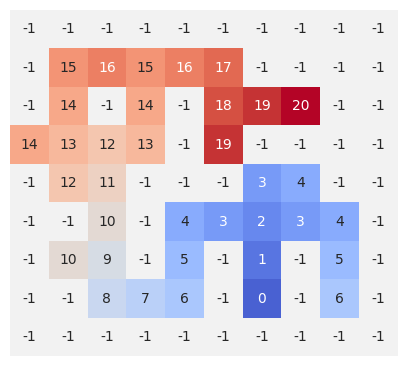

maze5.pdf
filepath = bookcode/4/inputs/maze6
Processing file: bookcode/4/inputs/maze6
distance from start to exit: 4
start at (7, 5)
numrow = 9, numcol = 8
exit at (8, 2)
    -1    -1    -1    13    -1    -1    -1    -1
    -1    10    11    12    13    14    15    -1
    10     9    -1    -1    14    -1    16    -1
    -1     8     9    10    -1     4    -1    -1
    -1     7    -1    -1    -1     3     4    -1
    -1     6     5     4     3     2    -1    -1
    -1     5    -1     3    -1     1    -1    -1
    -1     4     3     2     1     0     1    -1
    -1    -1     4    -1    -1    -1    -1    -1


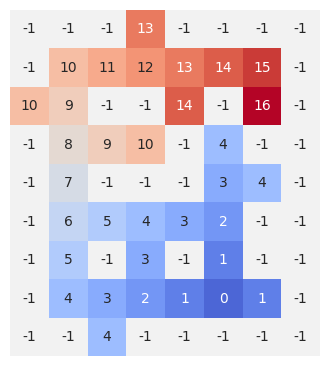

maze6.pdf
filepath = bookcode/4/inputs/maze7
Processing file: bookcode/4/inputs/maze7
distance from start to exit: 20
start at (3, 5)
numrow = 15, numcol = 13
exit at (8, 0)
    -1    -1    -1    -1    -1    -1    -1    -1    -1    -1    -1    -1    -1
    -1     6     5     4     3     2    -1     4     5     6     7     8    -1
    -1     5    -1    -1    -1     1    -1     3    -1     7    -1    -1    -1
    -1     4     3     2     1     0     1     2    -1     8     9    10    -1
    -1    -1     4     3    -1    -1     2     3    -1     7    -1    11    -1
    -1    22    -1     4     5     6    -1     4     5     6    -1    12    -1
    -1    21    -1    -1     6     7    -1    -1    -1     7    -1    11    -1
    -1    20    -1     8     7     8    -1    10     9     8     9    10    -1
    20    19    20    -1     8    -1    -1    -1    10    -1    -1    -1    -1
    -1    18    -1    10     9    10    11    12    11    12    -1    16    -1
    -1    17    -1    -1    -1    11

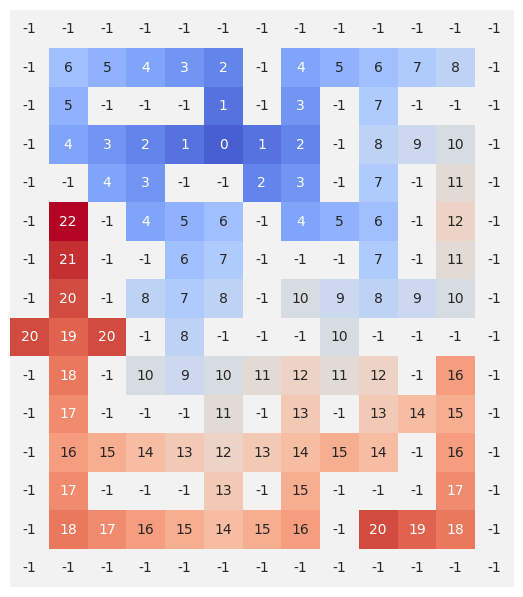

maze7.pdf
filepath = bookcode/4/inputs/maze8
Processing file: bookcode/4/inputs/maze8
Exit at (0, 7) is unreachable.
start at (3, 5)
numrow = 18, numcol = 15
exit at (0, 7)
    -1    -1    -1    -1    -1    -1    -1    -1    -1    -1    -1    -1    -1    -1
    -1     6     5     4     3     2    -1    -1    -1    -1    -1    -1    -1    -1
    -1     7    -1    -1    -1     1    -1    -1    -1    -1    -1    -1    -1
    -1     8     7     6    -1     0    -1    -1    -1    -1    -1    -1    -1    -1
    -1    -1    -1     5    -1     1    -1    -1    -1    -1    -1    -1    -1
    -1    -1    -1     4     3     2    -1    -1    -1    -1    -1    -1    -1
    -1    -1    -1    -1     4     3    -1    -1    -1    -1    -1    -1    -1    -1    -1
    -1    -1    -1     6     5     4    -1    -1    -1    -1    -1    -1    -1    -1    -1
    -1    -1    -1    -1    -1    -1    -1    -1    -1    -1    -1    -1    -1    -1
    -1    -1    -1    -1    -1    -1    -1    -1    -1    -1    -1  

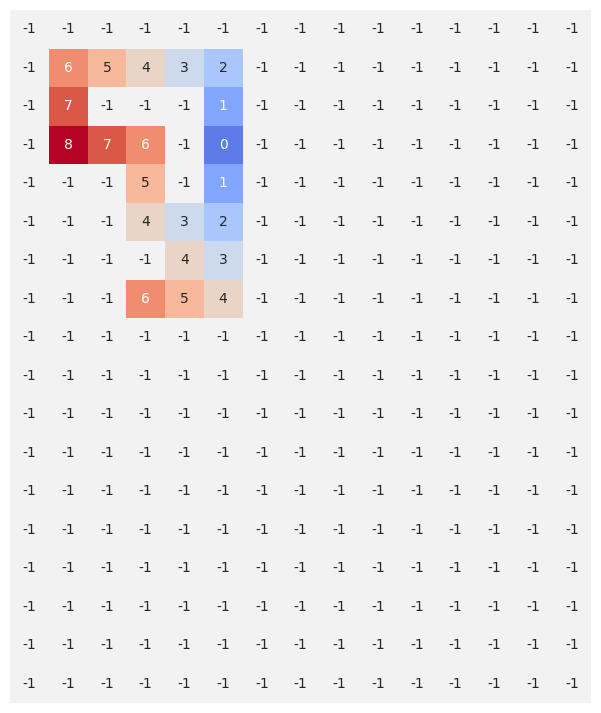

maze8.pdf
filepath = bookcode/4/inputs/maze9
Processing file: bookcode/4/inputs/maze9
distance from start to exit: 4
start at (2, 8)
numrow = 16, numcol = 22
exit at (0, 10)
    -1    -1    -1    -1    -1    -1    -1    -1    -1    -1     4    -1    -1    -1    -1    -1    -1    -1
    -1     8     7     6     5     4     3     2     1    -1     3     4     5     6     7     8    -1
    -1    -1    -1    -1    -1     5    -1     1     0     1     2    -1     6    -1    -1     9    10    -1    -1    -1    -1    -1
    -1    -1    -1     6     5     4     3     2     1     2    -1    16    -1    12    11    10    -1    -1    -1    -1    -1
    -1    -1    -1     7    -1    -1    -1     3    -1     3    -1    15    -1    13    -1    -1    -1    -1    -1    -1    -1
    -1    10     9     8    -1    -1    -1     4    -1     4    -1    14    15    14    15    16    -1    -1
    -1    -1    -1    -1    -1    -1    -1     5    -1    -1    -1    13    -1    15    -1    17    -1    -1    -1    

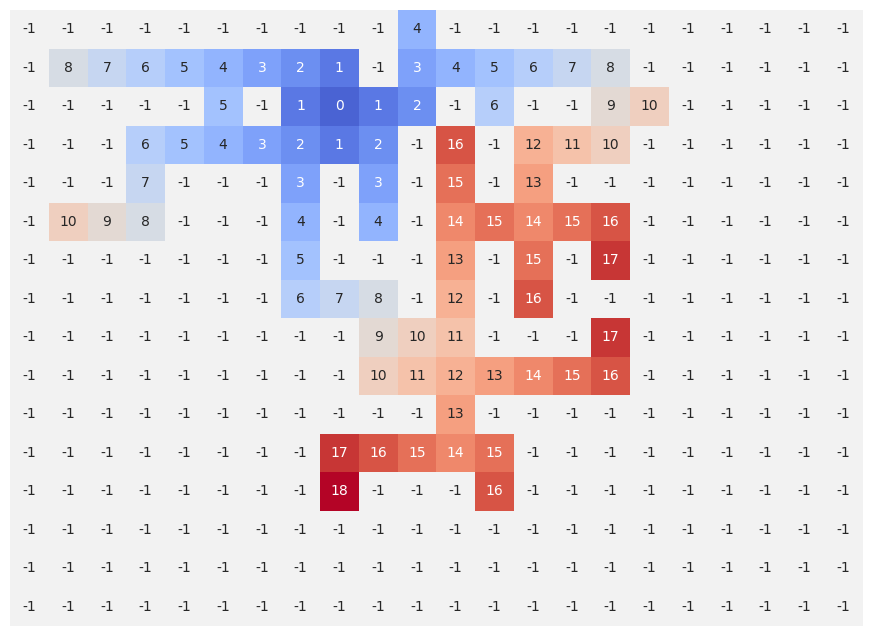

maze9.pdf


In [ ]:
input_path = 'bookcode/CH04/inputs/'
import os
if os.path.isdir(input_path):
  for filename in sorted(os.listdir(input_path)):
    filepath = os.path.join(input_path, filename)
    print(f'filepath = {filepath}')
    if os.path.isfile(filepath):
      print(f"Processing file: {filepath}")
      maz = Maze(filepath)
      maz.solve()
      maz.print()
      draw_heatmap (maz, filename)
else:
  print(f'{input_path} is not a directory')

In [ ]:
maze_path = 'https://raw.githubusercontent.com/icptwo/icp2/refs/heads/main/Part4/CH24/input4'
import urllib.request
maze_file = 'maze'
urllib.request.urlretrieve(maze_path, maze_file)
maz = Maze(maze_file)
maz.solve()
maz.print()

distance from start to exit: 18
start at (8, 9)
numrow = 16, numcol = 16
exit at (0, 1)
    -1    18    -1
    -1    17    16    17    -1
    -1    16    15    -1    13    12    -1
    -1    15    14    -1    12    11    -1    -1    -1
    -1    14    13    14    -1    10     9    -1    13    12    -1
    -1    13    12    -1    10     9     8     9    -1    11    10     9    -1
    -1    12    11    10     9     8     7     8     9    10     9     8     7    -1
    -1    -1    -1    -1    -1    -1     6     7    -1    -1    -1     7     6     7    -1
    -1    10     9     8    -1     6     5    -1     1     0     1    -1     5     6     7    -1
    -1     9     8     7     6     5     4     3     2     1     2     3     4    -1
    -1    10     9     8     7    -1     5     4     3     2     3    -1
    -1    11    10     9     8     9    -1     5     4     3    -1
    -1    12    11    10     9    10    -1     6    -1
    -1    13    -1    11    10    -1    -1    -1
    -1    14    

In [ ]:
'''
from google.colab import drive
drive.mount('/content/drive', force_remount = True)
input_path = '/content/drive/My Drive/Colab Notebooks/Recursion Book/CH04 Maze/examples/'
import os
if os.path.isdir(input_path):
  for filename in sorted(os.listdir(input_path)):
    filepath = os.path.join(input_path, filename)
    if os.path.isfile(filepath):
      print(f"Processing file: {filepath}")
      maz = Maze(filepath)
      maz.solve()
      maz.print()
      draw_heatmap (maz)
'''

'\nfrom google.colab import drive\ndrive.mount(\'/content/drive\', force_remount = True)\ninput_path = \'/content/drive/My Drive/Colab Notebooks/Recursion Book/CH04 Maze/examples/\'\nimport os\nif os.path.isdir(input_path):\n  for filename in sorted(os.listdir(input_path)):\n    filepath = os.path.join(input_path, filename)\n    if os.path.isfile(filepath):\n      print(f"Processing file: {filepath}")\n      maz = Maze(filepath)\n      maz.solve()\n      maz.print()\n      draw_heatmap (maz)\n'